In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline 
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn import metrics

In [3]:
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/drug200.csv'
my_data = pd.read_csv(url)
my_data

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [4]:
my_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [7]:
label_encoder = LabelEncoder()
my_data['Sex '] = label_encoder.fit_transform(my_data['Sex'])
my_data['BP'] = label_encoder.fit_transform(my_data['BP'])
my_data['Cholesterol'] = label_encoder.fit_transform(my_data['Cholesterol'])
my_data

,Age,Sex,BP,Cholesterol,Na_to_K,Drug,Sex
0,23,F,0,0,25.355,drugY,0
1,47,M,1,0,13.093,drugC,1
2,47,M,1,0,10.114,drugC,1
3,28,F,2,0,7.798,drugX,0
4,61,F,1,0,18.043,drugY,0
...,...,...,...,...,...,...,...
195,56,F,1,0,11.567,drugC,0
196,16,M,1,0,12.006,drugC,1
197,52,M,2,0,9.894,drugX,1
198,23,M,2,1,14.020,drugX,1


In [8]:
my_data.isnull().sum()

Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
Sex            0
dtype: int64

In [32]:
custom_map = {'drugA':0,'drugB':1,'drugC':2,'drugX':3,'drugY':4}
my_data['drug_num'] = my_data['Drug'].map(custom_map)
my_data['drug_num']

0      4
1      2
2      2
3      3
4      4
      ..
195    2
196    2
197    3
198    3
199    3
Name: drug_num, Length: 200, dtype: int64

In [33]:
my_data

,Age,Sex,BP,Cholesterol,Na_to_K,Drug,Sex,drug_num,sex
0,23,NaN,0,0,25.355,drugY,0,4,NaN
1,47,NaN,1,0,13.093,drugC,1,2,NaN
2,47,NaN,1,0,10.114,drugC,1,2,NaN
3,28,NaN,2,0,7.798,drugX,0,3,NaN
4,61,NaN,1,0,18.043,drugY,0,4,NaN
...,...,...,...,...,...,...,...,...,...
195,56,NaN,1,0,11.567,drugC,0,2,NaN
196,16,NaN,1,0,12.006,drugC,1,2,NaN
197,52,NaN,2,0,9.894,drugX,1,3,NaN
198,23,NaN,2,1,14.020,drugX,1,3,NaN


In [34]:
my_data.select_dtypes(include = ['object']).columns.tolist()
sex_map = {'F':1,'M':2}
my_data['Sex'] = my_data['Sex'].map(sex_map)
my_data

,Age,Sex,BP,Cholesterol,Na_to_K,Drug,Sex,drug_num,sex
0,23,NaN,0,0,25.355,drugY,0,4,NaN
1,47,NaN,1,0,13.093,drugC,1,2,NaN
2,47,NaN,1,0,10.114,drugC,1,2,NaN
3,28,NaN,2,0,7.798,drugX,0,3,NaN
4,61,NaN,1,0,18.043,drugY,0,4,NaN
...,...,...,...,...,...,...,...,...,...
195,56,NaN,1,0,11.567,drugC,0,2,NaN
196,16,NaN,1,0,12.006,drugC,1,2,NaN
197,52,NaN,2,0,9.894,drugX,1,3,NaN
198,23,NaN,2,1,14.020,drugX,1,3,NaN


In [36]:
my_data.drop('Drug',axis = 1).corr()['drug_num']

Age           -0.004828
Sex                 NaN
BP             0.372868
Cholesterol    0.055629
Na_to_K        0.589120
Sex           -0.098573
drug_num       1.000000
sex                 NaN
Name: drug_num, dtype: float64

In [37]:
my_data

,Age,Sex,BP,Cholesterol,Na_to_K,Drug,Sex,drug_num,sex
0,23,NaN,0,0,25.355,drugY,0,4,NaN
1,47,NaN,1,0,13.093,drugC,1,2,NaN
2,47,NaN,1,0,10.114,drugC,1,2,NaN
3,28,NaN,2,0,7.798,drugX,0,3,NaN
4,61,NaN,1,0,18.043,drugY,0,4,NaN
...,...,...,...,...,...,...,...,...,...
195,56,NaN,1,0,11.567,drugC,0,2,NaN
196,16,NaN,1,0,12.006,drugC,1,2,NaN
197,52,NaN,2,0,9.894,drugX,1,3,NaN
198,23,NaN,2,1,14.020,drugX,1,3,NaN


In [40]:
my_data.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug,Sex,drug_num,sex
0,23,NaN,0,0,25.355,drugY,0,4,NaN
1,47,NaN,1,0,13.093,drugC,1,2,NaN
2,47,NaN,1,0,10.114,drugC,1,2,NaN
3,28,NaN,2,0,7.798,drugX,0,3,NaN
4,61,NaN,1,0,18.043,drugY,0,4,NaN


In [41]:
my_data.drop(columns = 'sex',axis = 1)

,Age,Sex,BP,Cholesterol,Na_to_K,Drug,Sex,drug_num
0,23,NaN,0,0,25.355,drugY,0,4
1,47,NaN,1,0,13.093,drugC,1,2
2,47,NaN,1,0,10.114,drugC,1,2
3,28,NaN,2,0,7.798,drugX,0,3
4,61,NaN,1,0,18.043,drugY,0,4
...,...,...,...,...,...,...,...,...
195,56,NaN,1,0,11.567,drugC,0,2
196,16,NaN,1,0,12.006,drugC,1,2
197,52,NaN,2,0,9.894,drugX,1,3
198,23,NaN,2,1,14.020,drugX,1,3


In [42]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
%matplotlib inline
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn import metrics

path= 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/drug200.csv'
my_data = pd.read_csv(path)


label_encoder = LabelEncoder()
my_data['Sex'] = label_encoder.fit_transform(my_data['Sex'])
my_data['BP'] = label_encoder.fit_transform(my_data['BP'])
my_data['Cholesterol'] = label_encoder.fit_transform(my_data['Cholesterol'])

my_data.isnull().sum()
custum_nums = {'drugA':0,'drugB':1,'drugC':2,'drugX':3,'drugY':4}
my_data['Drug_num'] = my_data['Drug'].map(custum_nums)

my_data.drop('Drug',axis = 1).corr()['Drug_num']

Age           -0.004828
Sex           -0.098573
BP             0.372868
Cholesterol    0.055629
Na_to_K        0.589120
Drug_num       1.000000
Name: Drug_num, dtype: float64

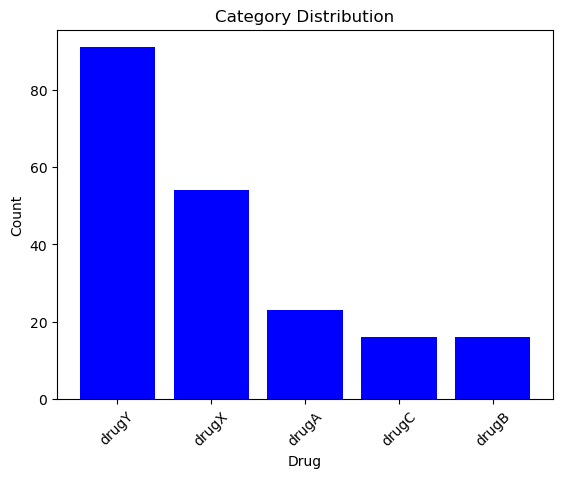

In [43]:
category_counts = my_data['Drug'].value_counts()

# Plot the count plot
plt.bar(category_counts.index, category_counts.values, color='blue')
plt.xlabel('Drug')
plt.ylabel('Count')
plt.title('Category Distribution')
plt.xticks(rotation=45)  # Rotate labels for better readability if needed
plt.show()

In [44]:
X= my_data.drop(['Drug','Drug_num'],axis = 1)
y = my_data['Drug']